### Load all libraries

In [1]:
import dask
import dask.distributed
import dask.utils
import numpy as np
import planetary_computer as pc
import xarray as xr
from IPython.display import display
from pystac_client import Client
import matplotlib.pyplot as plt
%matplotlib inline
from odc.stac import configure_rio, stac_load
import stackstac
import datetime
import rasterio
from skimage.segmentation import felzenszwalb
from skimage.segmentation import mark_boundaries
import skimage.exposure
import seaborn as sns
from pathlib import Path
import scipy
import scipy.ndimage
import os
import pyproj
from pyproj import CRS, Proj
from shapely.geometry import box
from rasterio.enums import Resampling
import time

In [2]:
# Set PROJ_LIB environment variable
os.environ['PROJ_LIB'] = r'C:\ProgramData\anaconda3\newenv\Library\share\proj'
print(os.environ['PROJ_LIB'])

C:\ProgramData\anaconda3\newenv\Library\share\proj


Masking invalid pixels

# Mask saturated pixels
def mask_saturated_pixels(data, max_value=11000):
    return data.where(data < max_value)

# Apply quality masks (SCL band)
def apply_quality_mask(data, scl_band):
    quality_mask = (scl_band == 4) | (scl_band == 5)  # Mask out clouds and shadows
    return data.where(~quality_mask)

The harmonize_to_old function harmonizes new (post January 25th, 2022) Sentinel 2 data to be compoarable to older data. It expects an xarray DataArray similar to those returned by stackstac.

In [3]:
# Define the harmonization function
def harmonize_to_old(data):
    """
    Harmonize new Sentinel-2 data to the old baseline.

    Parameters
    ----------
    data: xarray.DataArray
        A DataArray with four dimensions: time, band, y, x

    Returns
    -------
    harmonized: xarray.DataArray
        A DataArray with all values harmonized to the old
        processing baseline.
    """
    cutoff = datetime.datetime(2022, 1, 25)
    offset = 1000
    bands = [
        "B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B10", "B11", "B12"
    ]

    old = data.sel(time=slice(None, cutoff))
    new = data.sel(time=slice(cutoff, None))

    # Process only the specified bands
    to_process = list(set(bands) & set(data.coords['band'].data.tolist()))
    new_to_process = new.sel(band=to_process)

    # Clip and offset
    new_harmonized = new_to_process.clip(min=offset)
    new_harmonized -= offset

    # Combine the harmonized new data with the old data
    new = xr.concat([new.drop_sel(band=to_process), new_harmonized], "band").sel(band=data.coords['band'].data.tolist())
    return xr.concat([old, new], dim="time")

In [4]:
# Function to compute the data with retries
def compute_with_retries(data, max_retries=3, retry_delay=5):
    for attempt in range(max_retries):
        try:
            return data.compute()
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(retry_delay)
    return None

### Start Dask Client: for improving load speed significantly (optional)

In [5]:
# Disable the Dask diagnostic that causes the pynvml error
os.environ["DASK_DISTRIBUTED__ENABLE_NVML"] = "False"
dask.config.set({"distributed.diagnostics.nvml": False})

In [6]:
client = dask.distributed.Client()
configure_rio(cloud_defaults=True, client=client)
display(client)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 63.42 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:57747,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 16
Started: Just now,Total memory: 63.42 GiB
Comm: tcp://127.0.0.1:57767,Total threads: 4
Dashboard: http://127.0.0.1:57770/status,Memory: 15.86 GiB
Nanny: tcp://127.0.0.1:57750,


## Sentinel-2 dataset

### Query STAC API

In [7]:
# Looking for Sentinel dataset
catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=pc.sign_inplace)

query = catalog.search(
    collections=["sentinel-2-l2a"],
    datetime="2024-06-16",
    query={"s2:mgrs_tile": dict(eq="36RUV"), "eo:cloud_cover": {"lt": 4}},
)

items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 1 datasets


### Load the required bands

In [8]:
# Set CRS for each item
for item in items:
    item.properties['proj:epsg'] = 32636

# Load the data
xx = stackstac.stack(
    items,
    assets=["B02", "B03", "B04", "B05", "B08", "B11", "B12", "B06", "B07", "B8A", "SCL"],
    #assets=["B04", "B06", "B07", "B8A", "SCL"],
    resolution=10,
    fill_value=0,
    resampling=Resampling.nearest,
    #epsg=32636
    #crs="EPSG:32636",
)

print(f"Bands: {', '.join(list(xx.coords['band'].data))}")
display(xx)

Bands: B02, B03, B04, B05, B08, B11, B12, B06, B07, B8A, SCL


<xarray.DataArray 'stackstac-0327dd0f9ba70e53264fc3810e06baa9' (time: 1,
                                                                band: 11,
                                                                y: 10980,
                                                                x: 10980)> Size: 11GB
dask.array<fetch_raster_window, shape=(1, 11, 10980, 10980), dtype=float64, chunksize=(1, 1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/44)
  * time                                     (time) datetime64[ns] 8B 2024-06...
    id                                       (time) <U54 216B 'S2A_MSIL2A_202...
  * band                                     (band) <U3 132B 'B02' ... 'SCL'
  * x                                        (x) float64 88kB 3e+05 ... 4.098...
  * y                                        (y) float64 88kB 3.5e+06 ... 3.3...
    s2:dark_features_percentage              float64 8B 0.09216
    ...                                       ...
    gsd                                      (band) float64 88B 10.0 ... 20.0
    proj:bbox                                object 8B {300000.0, 3500040.0, ...
    common_name                              (band) object 88B 'blue' ... None
    center_wavelength                        (band) object 88B 0.49 ... None
    full_width_half_max                      (band) object 88B 0.098 ... None
    epsg                                     int32 4B 32636
Attributes:
    spec:        RasterSpec(epsg=32636, bounds=(300000, 3390240, 409800, 3500...
    crs:         epsg:32636
    transform:   | 10.00, 0.00, 300000.00|\n| 0.00,-10.00, 3500040.00|\n| 0.0...
    resolution:  10

# Mask saturated pixels
xx = mask_saturated_pixels(xx)

# Apply quality mask using the SCL band
scl_band = xx.sel(band='SCL')
xx = apply_quality_mask(xx, scl_band)

In [9]:
# Apply harmonization to adjust the new baseline data
xx_harmonized = harmonize_to_old(xx)

# Replace NaNs with zeros
xx_harmonized = xx_harmonized.fillna(0)

# Display the harmonized dataset
print(f"Bands after harmonization: {', '.join(list(xx_harmonized.coords['band'].data))}")
display(xx_harmonized)

Bands after harmonization: B02, B03, B04, B05, B08, B11, B12, B06, B07, B8A, SCL


<xarray.DataArray 'stackstac-0327dd0f9ba70e53264fc3810e06baa9' (time: 1,
                                                                band: 11,
                                                                y: 10980,
                                                                x: 10980)> Size: 11GB
dask.array<where, shape=(1, 11, 10980, 10980), dtype=float64, chunksize=(1, 1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/44)
  * time                                     (time) datetime64[ns] 8B 2024-06...
    id                                       (time) <U54 216B 'S2A_MSIL2A_202...
  * band                                     (band) <U3 132B 'B02' ... 'SCL'
  * x                                        (x) float64 88kB 3e+05 ... 4.098...
  * y                                        (y) float64 88kB 3.5e+06 ... 3.3...
    s2:dark_features_percentage              float64 8B 0.09216
    ...                                       ...
    gsd                                      (band) float64 88B 10.0 ... 20.0
    proj:bbox                                object 8B {300000.0, 3500040.0, ...
    common_name                              (band) object 88B 'blue' ... None
    center_wavelength                        (band) object 88B 0.49 ... None
    full_width_half_max                      (band) object 88B 0.098 ... None
    epsg                                     int32 4B 32636
Attributes:
    spec:        RasterSpec(epsg=32636, bounds=(300000, 3390240, 409800, 3500...
    crs:         epsg:32636
    transform:   | 10.00, 0.00, 300000.00|\n| 0.00,-10.00, 3500040.00|\n| 0.0...
    resolution:  10

#### Plot the bands

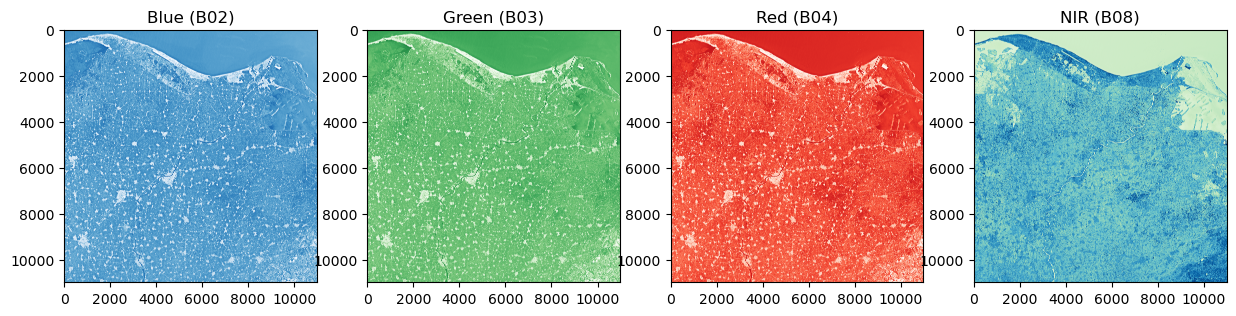

In [10]:
# Compute the data
xx_computed = compute_with_retries(xx)

# Checking the images with proper scaling
if xx_computed is not None:
    fig, ax = plt.subplots(1, 4, figsize=(15, 5))
    for i, band, cmap, title in zip(range(4), ['B02', 'B03', 'B04', 'B08'], ['Blues_r', 'Greens_r', 'Reds_r', 'GnBu'], ['Blue (B02)', 'Green (B03)', 'Red (B04)', 'NIR (B08)']):
    #for i, band, cmap, title in zip(range(4), ['B04', 'B06', 'B07', 'B8A'], ['Blues_r', 'Greens_r', 'Reds_r', 'GnBu'], ['Blue (B02)', 'Green (B03)', 'Red (B04)', 'NIR (B08)']):
        try:
            band_data = xx_computed.sel(band=band).values[0]  # Select the first time slice
            band_data = np.where(np.isnan(band_data), 0, band_data)  # Replace NaNs with zeros
            ax[i].imshow(band_data, cmap=cmap, vmin=0, vmax=np.percentile(band_data, 99))
            ax[i].set_title(title)
        except Exception as e:
            print(f"Error reading band {band}: {e}")
            ax[i].set_title(f"Error: {band}")
    plt.show()
else:
    print("Data could not be computed.")

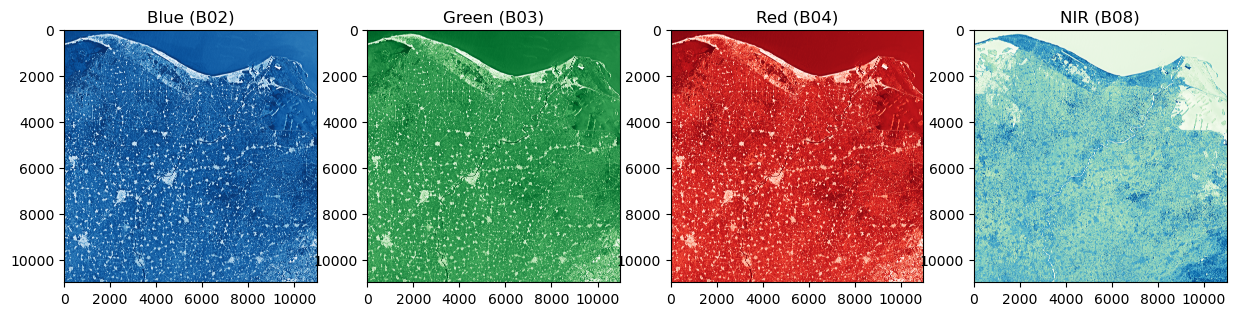

In [11]:
# Compute the harmonized data
xx_harmonized_computed = compute_with_retries(xx_harmonized)

# Checking the harmonized images with proper scaling
if xx_harmonized_computed is not None:
    fig, ax = plt.subplots(1, 4, figsize=(15, 5))
    for i, band, cmap, title in zip(range(4), ['B02', 'B03', 'B04', 'B08'], ['Blues_r', 'Greens_r', 'Reds_r', 'GnBu'], ['Blue (B02)', 'Green (B03)', 'Red (B04)', 'NIR (B08)']):
    #for i, band, cmap, title in zip(range(4), ['B04', 'B06', 'B07', 'B8A'], ['Blues_r', 'Greens_r', 'Reds_r', 'GnBu'], ['Blue (B02)', 'Green (B03)', 'Red (B04)', 'NIR (B08)']):
        try:
            band_data = xx_harmonized_computed.sel(band=band).values[0]  # Select the first time slice
            band_data = np.where(np.isnan(band_data), 0, band_data)  # Replace NaNs with zeros
            ax[i].imshow(band_data, cmap=cmap, vmin=0, vmax=np.percentile(band_data, 99))
            ax[i].set_title(title)
        except Exception as e:
            print(f"Error reading band {band}: {e}")
            ax[i].set_title(f"Error: {band}")
    plt.show()
else:
    print("Harmonized data could not be computed.")

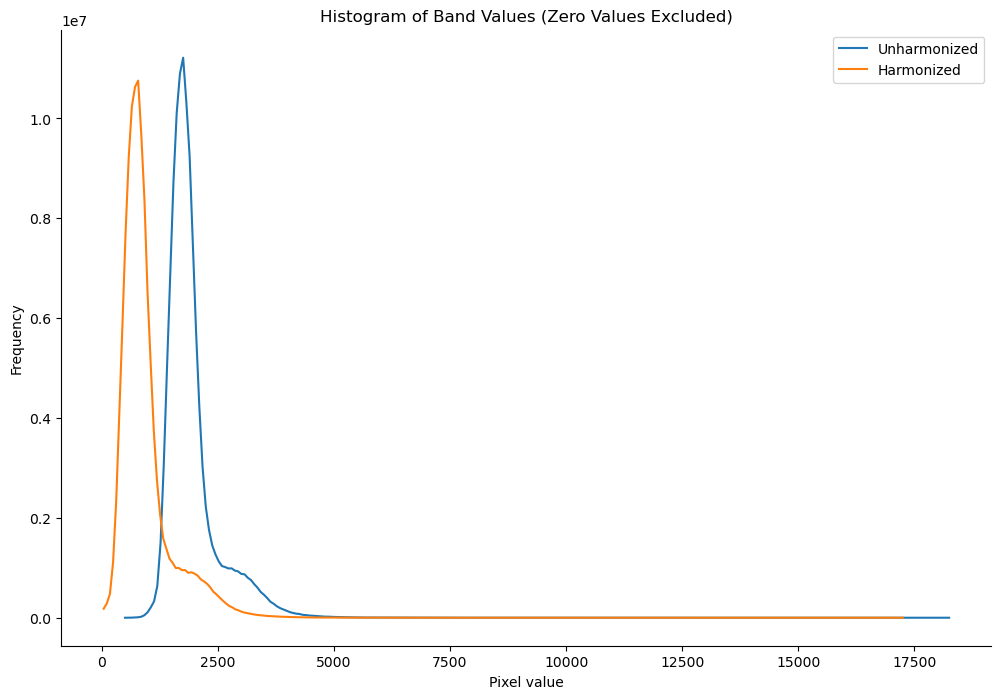

In [12]:
# Ensure that the data is computed if it's a dask array
xx_computed_band = xx_computed.isel(band=1).data
if hasattr(xx_computed_band, 'compute'):
    xx_computed_band = xx_computed_band.compute()

xx_harmonized_computed_band = xx_harmonized_computed.isel(band=1).data
if hasattr(xx_harmonized_computed_band, 'compute'):
    xx_harmonized_computed_band = xx_harmonized_computed_band.compute()

# Replace NaNs with zeros for histogram calculation
xx_computed_band = np.where(np.isnan(xx_computed_band), 0, xx_computed_band)
xx_harmonized_computed_band = np.where(np.isnan(xx_harmonized_computed_band), 0, xx_harmonized_computed_band)

# Filter out zero values
xx_computed_band_filtered = xx_computed_band[xx_computed_band != 0]
xx_harmonized_computed_band_filtered = xx_harmonized_computed_band[xx_harmonized_computed_band != 0]

fig, ax = plt.subplots(figsize=(12, 8))

# Calculate and plot histogram for unharmonized data
hist, bins = skimage.exposure.histogram(xx_computed_band_filtered)
ax.plot(bins, hist, label="Unharmonized")

# Calculate and plot histogram for harmonized data
hist, bins = skimage.exposure.histogram(xx_harmonized_computed_band_filtered)
ax.plot(bins, hist, label="Harmonized")

plt.legend()
sns.despine()
plt.xlabel('Pixel value')
plt.ylabel('Frequency')
plt.title('Histogram of Band Values (Zero Values Excluded)')
plt.show()

# Apply harmonization to adjust the new baseline data
xx_harmonized = harmonize_to_old(xx)

# Visualize before and after harmonization
def plot_band(data, title):
    plt.figure(figsize=(10, 6))
    plt.imshow(data, cmap='gray', vmin=np.percentile(data, 2), vmax=np.percentile(data, 98))
    plt.colorbar()
    plt.title(title)
    plt.show()

# Select a band for visualization, e.g., B02 (Blue)
band_to_plot = 'B02'
original_band_data = xx.sel(band=band_to_plot).values[0]
harmonized_band_data = xx_harmonized.sel(band=band_to_plot).values[0]

plot_band(original_band_data, f'Original {band_to_plot} Band')
plot_band(harmonized_band_data, f'Harmonized {band_to_plot} Band')

# Calculate histograms excluding zeros and NaNs
def plot_histogram(data, title):
    data_filtered = data#[(data != 0) & ~np.isnan(data)]
    hist, bins = np.histogram(data_filtered, bins=256)
    plt.figure(figsize=(10, 6))
    plt.plot(bins[:-1], hist)
    plt.title(title)
    plt.xlabel('Pixel value')
    plt.ylabel('Frequency')
    plt.show()

plot_histogram(original_band_data, f'Histogram of Original {band_to_plot} Band')
plot_histogram(harmonized_band_data, f'Histogram of Harmonized {band_to_plot} Band')

### Starting from 25 January 2022, a shift has been added to satellite images
Radiometric offset applied for each band. At 
L1C, for a given D1], the reflectan e
value is then equal 
to (DN+RA IO
_ADD_OFFSET) / QUANTIFICATION_V.A
For L2A, only RADIO _ADD_OFFSET will be added (-1000).LUEGAINS
UEi

In [13]:
blue_band = xx_harmonized_computed.sel(band='B02').values[0]
green_band = xx_harmonized_computed.sel(band='B03').values[0]
red_band = xx_harmonized_computed.sel(band='B04').values[0]  # Red band
B05_band = xx_harmonized_computed.sel(band='B05').values[0]
nir_band = xx_harmonized_computed.sel(band='B08').values[0]  # NIR band
B11_band = xx_harmonized_computed.sel(band='B11').values[0]
B12_band = xx_harmonized_computed.sel(band='B12').values[0]

In [14]:
B06_band = xx_harmonized_computed.sel(band='B06').values[0]
B07_band = xx_harmonized_computed.sel(band='B07').values[0]
B8A_band = xx_harmonized_computed.sel(band='B8A').values[0]

In [15]:
import gc
del xx_harmonized
del xx_computed
del xx_computed_band
del xx_harmonized_computed
del xx_harmonized_computed_band
gc.collect()

33935

### Calculating Vegetation indices

In [16]:
# Define a function for calculating the noramlized indices
def normalized_index(band1, band2, eps=0.0001):
    return (band1 - band2) / (band1 + band2)

#### NDVI index
Normalized difference vegetation index (NDVI) quantifies vegetation health using near-infrared (which is reflected by vegetation) and red light (which is absorbed by vegetation).

The sensitivity of the NDVI to soil background and atmospheric effects stimulates the development of new Vis, such as the soil-adjusted vegetation index (SAVI), optimized soil-adjusted vegetation index (OSAVI), and atmospherically resistant vegetation index (ARVI).

In [17]:
ndvi = normalized_index(nir_band, red_band)
#plt.imshow(ndvi, cmap = "RdYlGn")
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\952075499.py:3: RuntimeWarning: invalid value encountered in divide
  return (band1 - band2) / (band1 + band2)


### kNDVI
kernal Normalized difference vegetation index (kNDVI) is an improving performance of NDVI. To perform an automatic and pixel-wise adaptive stretching and guarantees that all moments of the relations between the NIR and red channels are taken into account. This also allows kNDVI to cope with saturation effects, complex phenological cycles, and seasonal variations, to deal with the mixed-pixel problem, and to propagate lower uncertainty than other indices. https://www.science.org/doi/10.1126/sciadv.abc7447

In [18]:
# kNDVI = tanh(((NIR - red) / 2 sigma)^2)
# sigma = 0.5 (NIR + red)
kndvi = np.tanh(((nir_band - red_band) / (2 * (0.5 * (nir_band + red_band))))**2)
#plt.imshow(kndvi, cmap = "RdYlGn", vmin=np.percentile(kndvi, 2), vmax=np.percentile(kndvi, 98))
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\2145050771.py:3: RuntimeWarning: invalid value encountered in divide
  kndvi = np.tanh(((nir_band - red_band) / (2 * (0.5 * (nir_band + red_band))))**2)


#### NDBI index
Normalized Difference Built-up Index (NDBI) uses the NIR and SWIR bands to emphasize manufactured built-up areas.

In [19]:
# Calculate NDBI without downscaling to SWIR
ndbi = normalized_index(B11_band, nir_band)
#plt.imshow(ndbi, cmap = "Set3", vmin=np.percentile(ndbi, 2), vmax=np.percentile(ndbi, 98))
#plt.colorbar()

#### DBSI
Dry Bare Soil Index (DBSI)  is a numerical indicator that combines blue, red, near infrared and short wave infrared spectral bands to capture soil variations. It is an inverse modified normalized difference index (MNDWI) adjusted by the normalized difference vegetation index (NDVI)

In [20]:
# DBSI = ((SWIR – GREEN) / (SWIR + GREEN) ) – NDVI
dbsi = normalized_index(B11_band, green_band) - ndvi
#plt.imshow(dbsi, cmap = "BrBG", vmin=np.percentile(dbsi, 2), vmax=np.percentile(dbsi, 98))
#plt.colorbar()

#### SAVI
Soil adjusted vegetation index (SAVI) is a vegetation index that attempts to minimize soil brightness influences using a soil-brightness correction factor. This is often used in arid regions where vegetative cover is low, and it outputs values between -1.0 and 1.0.

In [21]:
# SAVI= 1.5(NIR – R) (NIR+R+0.5)
savi = 1.5 * (nir_band - red_band) * (nir_band + red_band + 0.5)
#plt.imshow(savi, cmap = "BrBG", vmin=np.percentile(savi, 2), vmax=np.percentile(savi, 98))
#plt.colorbar()

#### OSAVI
Optimized soil adjusted vegetation index (OSAVI) is a modified SAVI and also uses reflectance in the NIR and red spectrum. The difference between the two indices is that OSAVI takes into account the standard value of the canopy background adjustment factor (0.16).

In [22]:
# OSAVI= 1.16(NIR – R)/ (NIR+R+0.16)
osavi = 1.16 * (nir_band - red_band) * (nir_band + red_band + 0.16)
#plt.imshow(osavi, cmap = "BrBG", vmin=np.percentile(osavi, 2), vmax=np.percentile(osavi, 98))
#plt.colorbar()

#### NDWI
Normal Difference Water Index (NDWI) is used to highlight open water features in a satellite image, allowing a water body to “stand out” against the soil and vegetation. NDWI index effectively measures moisture content.

In [23]:
# NDWI = (GREEN - NIR) / (GREEN + NIR)
ndwi = normalized_index(green_band, nir_band)
#plt.imshow(ndwi, cmap = "RdBu", vmin=np.percentile(ndwi, 2), vmax=np.percentile(ndwi, 98))
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\952075499.py:3: RuntimeWarning: invalid value encountered in divide
  return (band1 - band2) / (band1 + band2)


#### NDMI
Difference Moisture Index (NDMI) is used to determine vegetation water content which helps in monitoring the drought condition of the areas

In [24]:
# NDMI = (NIR - SWIR) / (NIR + SWIR)
ndmi = normalized_index(nir_band, B11_band)
#plt.imshow(ndmi, cmap = "RdBu", vmin=np.percentile(ndmi, 2), vmax=np.percentile(ndmi, 98))
#plt.colorbar()

#### MNDWI
Modified Normalized Difference Water Index (MNDWI) effectively differentiates between water and urban areas in satellite images. 
The MNDWI values were positive for water features (cropped area inundated with water) even vegetation was mixed with water because NIR band is not used for calculation of MNDWI. These results suggest that MNDWI is more sensitive to water features mixed with vegetation than NDWI due to positive values of MNDWI.

In [25]:
# MNDWI = (GREEN − SWIR1)/(GREEN + SWIR1)
mndmi = normalized_index(green_band, B11_band)
#plt.imshow(mndmi, cmap = "RdBu", vmin=np.percentile(mndmi, 2), vmax=np.percentile(mndmi, 98))
#plt.colorbar()

#### WRI
Water Ratio Index (WRI) can be used to determine the amount of moisture in the vegetation cover.

In [26]:
# WRI = (GREEN + RED)/(NIR + SWIR1)
wri = (green_band + red_band) / (nir_band + B11_band)
#plt.imshow(wri, cmap = "RdBu", vmin=0, vmax=8)
#plt.colorbar()

#### AWEI
Automated Water Extraction Index (AWEI) aims to enhance land cover classification accuracy into binary water and non-water under various environmental conditions.

In [27]:
# AWEIsh = BLUE + 2.5 × GREEN − 1.5 × (NIR + SWIR1) − 0.25 × SWIR2
awei = blue_band + 2.5 * green_band - 1.5 * (nir_band + B11_band) - 0.25 * B12_band
#plt.imshow(awei, cmap = "RdBu", vmin=np.percentile(awei, 2), vmax=np.percentile(awei, 98))
#plt.colorbar()

#### STR
 Shortwave infrared transformed reflectance (STR) for bare soils for two SWIR bands (B11 and B12).

In [28]:
# STR = (1 - SWIR)2 / 2 SWIR
# First for SWIR 1
str11 = ((1 - B11_band)**2) / (2 *B11_band)
#plt.imshow(str11, cmap = "RdBu", vmin=np.percentile(str11, 2), vmax=np.percentile(str11, 98))
#plt.colorbar()

In [29]:
# STR = (1 - SWIR)2 / 2 SWIR
# Second for SWIR 2
str12 = ((1 - B12_band)**2) / (2 * B12_band)
#plt.imshow(str12, cmap = "RdBu", vmin=np.percentile(str12, 2), vmax=np.percentile(str12, 98))
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\2368742671.py:3: RuntimeWarning: divide by zero encountered in divide
  str12 = ((1 - B12_band)**2) / (2 * B12_band)


In [30]:
# Get the average of SWIR 1 and 2
stravg = (str11 + str12) / 2
#plt.imshow(stravg, cmap = "RdBu", vmin=np.percentile(stravg, 2), vmax=np.percentile(stravg, 98))
#plt.colorbar()

#### RVI
Ratio vegetation index (RVI)  has the potential to indicate the stress level of crops, due to its high correlation with the leaf area, dry biomass and chlorophyll content

In [31]:
# RVI=NIR/R
rvi1 = nir_band / red_band
#plt.imshow(rvi1, cmap = 'RdYlGn', vmin=0, vmax=5)
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\1509962625.py:2: RuntimeWarning: divide by zero encountered in divide
  rvi1 = nir_band / red_band
C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\1509962625.py:2: RuntimeWarning: invalid value encountered in divide
  rvi1 = nir_band / red_band


In [32]:
# Ratio vegetation index 2 (RVI2)
# RVI2=NIR/G
rvi2 = nir_band / green_band
#plt.imshow(rvi2, cmap = 'RdYlGn', vmin=0, vmax=5)
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\516323251.py:3: RuntimeWarning: divide by zero encountered in divide
  rvi2 = nir_band / green_band
C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\516323251.py:3: RuntimeWarning: invalid value encountered in divide
  rvi2 = nir_band / green_band


#### TVI
Triangular vegetation index (TVI) is calculated as the area of a hypothetical triangle in spectral space that connects (1) green peak reflectance, (2) minimum chlorophyll absorption, and (3) the NIR shoulder. TVI has higher coefficient of determination for the same variable with positive values and the variances of the ratio are proportional to mean values.

In [33]:
# TVI= 60(NIR – G) – 100(R – G)
tvi = 60 * (nir_band - green_band) - 100 * (red_band - green_band)
#plt.imshow(tvi, cmap = 'RdYlGn', vmin=np.percentile(tvi, 2), vmax=np.percentile(tvi, 98))
#plt.colorbar()

#### EVI
Enhanced vegetation index (EVI) is similar to Normalized Difference Vegetation Index (NDVI) and can be used to quantify vegetation greenness. However, EVI corrects for some atmospheric conditions and canopy background noise and is more sensitive in areas with dense vegetation.

In [34]:
# EVI = G * ((NIR - R) / (NIR + C1 * R – C2 * B + L))
# EVI = 2.5 * ((NIR – R) / (NIR + 6 * R – 7.5 * B + 1))
evi = 2.5 * ((nir_band - red_band) / (nir_band + 6 * red_band - 7.5 * blue_band + 1))
#plt.imshow(evi, cmap = 'RdYlGn', vmin=-3, vmax=3)
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\483198539.py:3: RuntimeWarning: divide by zero encountered in divide
  evi = 2.5 * ((nir_band - red_band) / (nir_band + 6 * red_band - 7.5 * blue_band + 1))
C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\483198539.py:3: RuntimeWarning: invalid value encountered in divide
  evi = 2.5 * ((nir_band - red_band) / (nir_band + 6 * red_band - 7.5 * blue_band + 1))


#### GI
Green Index (GI) is used to estimate the content of leaf chlorophyll in various species of plants.

In [35]:
# GI=G/R
gi = green_band / red_band
#plt.imshow(gi, cmap = 'RdYlGn', vmin=0, vmax=2)
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\2065144491.py:2: RuntimeWarning: divide by zero encountered in divide
  gi = green_band / red_band
C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\2065144491.py:2: RuntimeWarning: invalid value encountered in divide
  gi = green_band / red_band


#### CGI
Green Chlorophyll Vegetation Index (GCI) 

In [36]:
# GCI = NIR / GREEN – 1
cgi = nir_band / green_band -1
#plt.imshow(cgi, cmap = 'RdYlGn', vmin=np.percentile(cgi, 2), vmax=np.percentile(cgi, 98))
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\266829157.py:2: RuntimeWarning: divide by zero encountered in divide
  cgi = nir_band / green_band -1
C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\266829157.py:2: RuntimeWarning: invalid value encountered in divide
  cgi = nir_band / green_band -1


#### GNDVI
Green normalized difference vegetation index (GNDVI)  is a vegetation index for estimating photo synthetic activity and is a commonly used vegetation index to determine water and nitrogen uptake into the plant canopy. GNDVI is more sensitive to chlorophyll variation in the crop than NDVI and has a higher saturation point. 

In [37]:
# GNDVI= (NIR – G)/ (NIR+G)
gndvi = normalized_index(nir_band, green_band)
#plt.imshow(gndvi, cmap = "RdYlGn", vmin=np.percentile(gndvi, 2), vmax=np.percentile(gndvi, 98))
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\952075499.py:3: RuntimeWarning: invalid value encountered in divide
  return (band1 - band2) / (band1 + band2)


The estimation of the ratio of carotenoid concentration to chlorophyll one (Car/Chl) can be important for the diagnosis of stress changes in plants. It is known that the degradation of chlorophylls under the action of stressors or at senescence is faster than the degradation of carotenoids. These indices are:

#### SRPI
Simple ratio pigment index (SRPI) defined as the ratio between blue and red reflectance

In [38]:
# SRPI=B/R
srpi = blue_band / red_band
#plt.imshow(srpi, cmap = 'RdYlGn', vmin=0, vmax=1)
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\2129945085.py:2: RuntimeWarning: divide by zero encountered in divide
  srpi = blue_band / red_band
C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\2129945085.py:2: RuntimeWarning: invalid value encountered in divide
  srpi = blue_band / red_band


#### NDPI
Normalized Difference Pond Index (NDPI) used in conjunction with NDVI, provides better discrimination of the aquatic and wetland vegetation from the
normal vegetation compared to the NDVI, which detects all types of vegetation. 

In [39]:
# NDPI = (SWIR1‐ Green)/(SWIR1+Green)
ndpi = normalized_index(B11_band, green_band)
#plt.imshow(ndpi, cmap = "RdYlGn", vmin=np.percentile(ndpi, 2), vmax=np.percentile(ndpi, 98))
#plt.colorbar()

#### SIPI
Structure insensitive pigment index (SIPI). Increases in SIPI are thought to indicate increased canopy stress (carotenoid pigment).

In [40]:
# SIPI= (NIR – B)/(NIR+B)
sipi = normalized_index(nir_band, blue_band)
#plt.imshow(sipi, cmap = "RdYlGn", vmin=np.percentile(sipi, 2), vmax=np.percentile(sipi, 98))
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\952075499.py:3: RuntimeWarning: invalid value encountered in divide
  return (band1 - band2) / (band1 + band2)


#### NPCI
Normalized pigment chlorophyll index (NPCI). Varied with total pigments/chl

In [41]:
# NPCI= (R – B)/(R+B)
npci = normalized_index(red_band, blue_band)
#plt.imshow(npci, cmap = "RdYlGn", vmin=np.percentile(npci, 2), vmax=np.percentile(npci, 98))
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\952075499.py:3: RuntimeWarning: invalid value encountered in divide
  return (band1 - band2) / (band1 + band2)


#### NDCI
Normalized Difference Chlorophyll Index (NDCI) was originally proposed for use to predict chlorophyll-a concentration using satellite remote sensing data in estuarine and coastal turbid productive waters and has since been applied for inland freshwater lake assessments.

In [42]:
# NDCI = (B5 – B4) / (B5 + B4)
ndci = normalized_index(B05_band, red_band)
#plt.imshow(ndci, cmap = "RdYlGn", vmin=np.percentile(ndci, 2), vmax=np.percentile(ndci, 98))
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\952075499.py:3: RuntimeWarning: invalid value encountered in divide
  return (band1 - band2) / (band1 + band2)


#### PSRI
Plant senescence reflectance index (PSRI). An increase in PSRI indicates increased canopy stress (carotenoid pigment), the onset of canopy senescence, and plant fruit ripening.

In [43]:
# PSRI= (B – R)/G
psri = (blue_band - red_band) / green_band
#plt.imshow(psri, cmap = "RdYlGn", vmin=np.percentile(psri, 2), vmax=np.percentile(psri, 98))
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\2571633349.py:2: RuntimeWarning: divide by zero encountered in divide
  psri = (blue_band - red_band) / green_band
C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\2571633349.py:2: RuntimeWarning: invalid value encountered in divide
  psri = (blue_band - red_band) / green_band


#### NDVIgb
Normalized difference vegetation index 2 (NDVIgb)

In [44]:
# NDVIgb= (G – B)/(G+B)
ndvigb = normalized_index(green_band, blue_band)
#plt.imshow(ndvigb, cmap = "RdYlGn", vmin=np.percentile(ndvigb, 2), vmax=np.percentile(ndvigb, 98))
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\952075499.py:3: RuntimeWarning: invalid value encountered in divide
  return (band1 - band2) / (band1 + band2)


#### VARI
Visible Atmospheric Resistant Index (VARI) is a vegetation index for estimating vegetation fraction quantitatively with only the visible range of the spectrum.

In [45]:
# VARI= (G – R)/(G+R – B)
vari = (green_band - red_band) / (green_band + red_band - blue_band)
#plt.imshow(vari, cmap = "RdYlGn", vmin=np.percentile(vari, 2), vmax=np.percentile(vari, 98))
#plt.colorbar()

C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\1303160595.py:2: RuntimeWarning: divide by zero encountered in divide
  vari = (green_band - red_band) / (green_band + red_band - blue_band)
C:\Users\Mona'asus\AppData\Local\Temp\ipykernel_38252\1303160595.py:2: RuntimeWarning: invalid value encountered in divide
  vari = (green_band - red_band) / (green_band + red_band - blue_band)


### Save the calculated vegetative indices as geotiff file.

In [46]:
# Get the height and width of veg. index
ndvi.shape[0], ndvi.shape[1]

(10980, 10980)

In [47]:
resdict = query.item_collection_as_dict()
resdict

{'type': 'FeatureCollection',
 'features': [{'id': 'S2A_MSIL2A_20240616T082611_R021_T36RUV_20240616T141406',
   'bbox': [30.891506, 30.6280708, 32.0586861, 31.6320042],
   'type': 'Feature',
   'links': [{'rel': 'collection',
     'type': 'application/json',
     'href': 'https://planetarycomputer.microsoft.com/api/stac/v1/collections/sentinel-2-l2a'},
    {'rel': 'parent',
     'type': 'application/json',
     'href': 'https://planetarycomputer.microsoft.com/api/stac/v1/collections/sentinel-2-l2a'},
    {'rel': 'root',
     'type': 'application/json',
     'href': 'https://planetarycomputer.microsoft.com/api/stac/v1/'},
    {'rel': 'self',
     'type': 'application/geo+json',
     'href': 'https://planetarycomputer.microsoft.com/api/stac/v1/collections/sentinel-2-l2a/items/S2A_MSIL2A_20240616T082611_R021_T36RUV_20240616T141406'},
    {'rel': 'license',
     'href': 'https://sentinel.esa.int/documents/247904/690755/Sentinel_Data_Legal_Notice'},
    {'rel': 'preview',
     'href': 'http

In [48]:
src = resdict['features'][0]['assets']['B04']['href']
src

'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/36/R/UV/2024/06/16/S2A_MSIL2A_20240616T082611_N0510_R021_T36RUV_20240616T141406.SAFE/GRANULE/L2A_T36RUV_A046922_20240616T083138/IMG_DATA/R10m/T36RUV_20240616T082611_B04_10m.tif?st=2026-01-02T14%3A04%3A47Z&se=2026-01-04T14%3A04%3A47Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-01-03T02%3A10%3A42Z&ske=2026-01-10T02%3A10%3A42Z&sks=b&skv=2025-07-05&sig=Y5C1dZLIdsUiYWx99GgQg8VtK1cBty02hJ3UJuPtIys%3D'

In [49]:
trans = resdict['features'][0]['assets']['B04']['proj:transform']
trans

[10.0, 0.0, 300000.0, 0.0, -10.0, 3500040.0]

In [50]:
dt = resdict['features'][0]['properties']['datetime'][0:10]
dt

'2024-06-16'

In [51]:
src = CRS.from_epsg(32636)
src
#src.to_wkt

<Projected CRS: EPSG:32636>
Name: WGS 84 / UTM zone 36N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 30°E and 36°E, northern hemisphere between equator and 84°N, onshore and offshore. Belarus. Cyprus. Egypt. Ethiopia. Finland. Israel. Jordan. Kenya. Lebanon. Moldova. Norway. Russian Federation. Saudi Arabia. Sudan. Syria. Türkiye (Turkey). Uganda. Ukraine.
- bounds: (30.0, 0.0, 36.0, 84.0)
Coordinate Operation:
- name: UTM zone 36N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [52]:
# Save NDVI calculated index as geotiff
img_path = os.path.join('sentinel2', 'ndvi_'+ dt +'.tif')
ndvi_tif = rasterio.open(img_path, 'w', driver='GTiff',
                            height = ndvi.shape[0], width = ndvi.shape[1],
                            count=1, dtype=str(ndvi.dtype),
                            crs='EPSG:32636', #src, #
                            transform=trans)

ndvi_tif.write(ndvi, 1)
ndvi_tif.close()

In [53]:
ndvi_href = "sentinel2/ndvi_" + dt + ".tif"
with rasterio.open(ndvi_href) as dataset:
    ndvi_bbox = list(dataset.bounds)
    ndvi_transform = list(dataset.transform)
    ndvi_shape = [dataset.height, dataset.width]
    bounds = dataset.bounds
    crs = dataset.crs

print('ndvi_bbox: ', ndvi_bbox, '\n')
print('ndvi_transform: ', ndvi_transform, '\n')
print('ndvi_shape: ', ndvi_shape, '\n')

ndvi_bbox:  [300000.0, 3390240.0, 409800.0, 3500040.0] 

ndvi_transform:  [10.0, 0.0, 300000.0, 0.0, -10.0, 3500040.0, 0.0, 0.0, 1.0] 

ndvi_shape:  [10980, 10980] 



#### Save the other calculated indices

In [54]:
img_path = os.path.join('sentinel2', 'kndvi_'+ dt +'.tif')
kndvi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=kndvi.shape[0], width=kndvi.shape[1], 
                         count=1, dtype=str(kndvi.dtype), crs='EPSG:32636', transform=trans)
kndvi_tif.write(kndvi, 1)
kndvi_tif.close()

In [55]:
img_path = os.path.join('sentinel2', 'ndbi_'+ dt +'.tif')
ndbi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=ndbi.shape[0], width=ndbi.shape[1], 
                         count=1, dtype=str(ndbi.dtype), crs='EPSG:32636', transform=trans)
ndbi_tif.write(ndbi, 1)
ndbi_tif.close()

In [56]:
img_path = os.path.join('sentinel2', 'dbsi_'+ dt +'.tif')
dbsi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=dbsi.shape[0], width=dbsi.shape[1], 
                         count=1, dtype=str(dbsi.dtype), crs='EPSG:32636', transform=trans)
dbsi_tif.write(dbsi, 1)
dbsi_tif.close()

In [57]:
img_path = os.path.join('sentinel2', 'savi_'+ dt +'.tif')
savi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=savi.shape[0], width=savi.shape[1], 
                         count=1, dtype=str(savi.dtype), crs='EPSG:32636', transform=trans)
savi_tif.write(savi, 1)
savi_tif.close()

In [58]:
img_path = os.path.join('sentinel2', 'osavi_'+ dt +'.tif')
osavi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=osavi.shape[0], width=osavi.shape[1], 
                         count=1, dtype=str(osavi.dtype), crs='EPSG:32636', transform=trans)
osavi_tif.write(osavi, 1)
osavi_tif.close()

In [59]:
img_path = os.path.join('sentinel2', 'ndwi_'+ dt +'.tif')
ndwi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=ndwi.shape[0], width=ndwi.shape[1], 
                         count=1, dtype=str(ndwi.dtype), crs='EPSG:32636', transform=trans)
ndwi_tif.write(ndwi, 1)
ndwi_tif.close()

In [60]:
img_path = os.path.join('sentinel2', 'ndmi_'+ dt +'.tif')
ndmi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=ndmi.shape[0], width=ndmi.shape[1], 
                         count=1, dtype=str(ndmi.dtype), crs='EPSG:32636', transform=trans)
ndmi_tif.write(ndmi, 1)
ndmi_tif.close()

In [61]:
img_path = os.path.join('sentinel2', 'mndmi_'+ dt +'.tif')
mndmi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=mndmi.shape[0], width=mndmi.shape[1], 
                         count=1, dtype=str(mndmi.dtype), crs='EPSG:32636', transform=trans)
mndmi_tif.write(mndmi, 1)
mndmi_tif.close()

In [62]:
img_path = os.path.join('sentinel2', 'wri_'+ dt +'.tif')
wri_tif = rasterio.open(img_path, 'w', driver='GTiff', height=wri.shape[0], width=wri.shape[1], 
                         count=1, dtype=str(wri.dtype), crs='EPSG:32636', transform=trans)
wri_tif.write(wri, 1)
wri_tif.close()

In [63]:
img_path = os.path.join('sentinel2', 'awei_'+ dt +'.tif')
awei_tif = rasterio.open(img_path, 'w', driver='GTiff', height=awei.shape[0], width=awei.shape[1], 
                         count=1, dtype=str(awei.dtype), crs='EPSG:32636', transform=trans)
awei_tif.write(awei, 1)
awei_tif.close()

In [64]:
img_path = os.path.join('sentinel2', 'str11_'+ dt +'.tif')
str11_tif = rasterio.open(img_path, 'w', driver='GTiff', height=str11.shape[0], width=str11.shape[1], 
                         count=1, dtype=str(str11.dtype), crs='EPSG:32636', transform=trans)
str11_tif.write(str11, 1)
str11_tif.close()

In [65]:
img_path = os.path.join('sentinel2', 'str12_'+ dt +'.tif')
str12_tif = rasterio.open(img_path, 'w', driver='GTiff', height=str12.shape[0], width=str12.shape[1], 
                         count=1, dtype=str(str12.dtype), crs='EPSG:32636', transform=trans)
str12_tif.write(str12, 1)
str12_tif.close()

In [66]:
img_path = os.path.join('sentinel2', 'stravg_'+ dt +'.tif')
stravg_tif = rasterio.open(img_path, 'w', driver='GTiff', height=stravg.shape[0], width=stravg.shape[1], 
                         count=1, dtype=str(stravg.dtype), crs='EPSG:32636', transform=trans)
stravg_tif.write(stravg, 1)
stravg_tif.close()

In [67]:
img_path = os.path.join('sentinel2', 'rvi1_'+ dt +'.tif')
rvi1_tif = rasterio.open(img_path, 'w', driver='GTiff', height=rvi1.shape[0], width=rvi1.shape[1], 
                         count=1, dtype=str(rvi1.dtype), crs='EPSG:32636', transform=trans)
rvi1_tif.write(rvi1, 1)
rvi1_tif.close()

In [68]:
img_path = os.path.join('sentinel2', 'rvi2_'+ dt +'.tif')
rvi2_tif = rasterio.open(img_path, 'w', driver='GTiff', height=rvi2.shape[0], width=rvi2.shape[1], 
                         count=1, dtype=str(rvi2.dtype), crs='EPSG:32636', transform=trans)
rvi2_tif.write(rvi2, 1)
rvi2_tif.close()

In [69]:
img_path = os.path.join('sentinel2', 'tvi_'+ dt +'.tif')
tvi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=tvi.shape[0], width=tvi.shape[1], 
                         count=1, dtype=str(tvi.dtype), crs='EPSG:32636', transform=trans)
tvi_tif.write(tvi, 1)
tvi_tif.close()

In [70]:
img_path = os.path.join('sentinel2', 'evi_'+ dt +'.tif')
evi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=evi.shape[0], width=evi.shape[1], 
                         count=1, dtype=str(evi.dtype), crs='EPSG:32636', transform=trans)
evi_tif.write(evi, 1)
evi_tif.close()

In [71]:
img_path = os.path.join('sentinel2', 'gi_'+ dt +'.tif')
gi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=gi.shape[0], width=gi.shape[1], 
                         count=1, dtype=str(gi.dtype), crs='EPSG:32636', transform=trans)
gi_tif.write(gi, 1)
gi_tif.close()

In [72]:
img_path = os.path.join('sentinel2', 'cgi_'+ dt +'.tif')
cgi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=cgi.shape[0], width=cgi.shape[1], 
                         count=1, dtype=str(cgi.dtype), crs='EPSG:32636', transform=trans)
cgi_tif.write(cgi, 1)
cgi_tif.close()

In [73]:
img_path = os.path.join('sentinel2', 'gndvi_'+ dt +'.tif')
gndvi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=gndvi.shape[0], width=gndvi.shape[1], 
                         count=1, dtype=str(gndvi.dtype), crs='EPSG:32636', transform=trans)
gndvi_tif.write(gndvi, 1)
gndvi_tif.close()

In [74]:
img_path = os.path.join('sentinel2', 'srpi_'+ dt +'.tif')
srpi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=srpi.shape[0], width=srpi.shape[1], 
                         count=1, dtype=str(srpi.dtype), crs='EPSG:32636', transform=trans)
srpi_tif.write(srpi, 1)
srpi_tif.close()

In [75]:
img_path = os.path.join('sentinel2', 'ndpi_'+ dt +'.tif')
ndpi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=ndpi.shape[0], width=ndpi.shape[1], 
                         count=1, dtype=str(ndpi.dtype), crs='EPSG:32636', transform=trans)
ndpi_tif.write(ndpi, 1)
ndpi_tif.close()

In [76]:
img_path = os.path.join('sentinel2', 'sipi_'+ dt +'.tif')
sipi_tif = rasterio.open(img_path, 'w', driver='GTiff', height=sipi.shape[0], width=sipi.shape[1], 
                         count=1, dtype=str(sipi.dtype), crs='EPSG:32636', transform=trans)
sipi_tif.write(sipi, 1)
sipi_tif.close()

In [77]:
img_path = os.path.join('sentinel2', 'npci_'+ dt +'.tif')
npci_tif = rasterio.open(img_path, 'w', driver='GTiff', height=npci.shape[0], width=npci.shape[1], 
                         count=1, dtype=str(npci.dtype), crs='EPSG:32636', transform=trans)
npci_tif.write(npci, 1)
npci_tif.close()

In [78]:
img_path = os.path.join('sentinel2', 'ndci_'+ dt +'.tif')
ndci_tif = rasterio.open(img_path, 'w', driver='GTiff', height=ndci.shape[0], width=ndci.shape[1], 
                         count=1, dtype=str(ndci.dtype), crs='EPSG:32636', transform=trans)
ndci_tif.write(ndci, 1)
ndci_tif.close()

In [79]:
img_path = os.path.join('sentinel2', 'psri_'+ dt +'.tif')
psri_tif = rasterio.open(img_path, 'w', driver='GTiff', height=psri.shape[0], width=psri.shape[1], 
                         count=1, dtype=str(psri.dtype), crs='EPSG:32636', transform=trans)
psri_tif.write(psri, 1)
psri_tif.close()

In [80]:
img_path = os.path.join('sentinel2', 'ndvigb_'+ dt +'.tif')
ndvigb_tif = rasterio.open(img_path, 'w', driver='GTiff', height=ndvigb.shape[0], width=ndvigb.shape[1], 
                         count=1, dtype=str(ndvigb.dtype), crs='EPSG:32636', transform=trans)
ndvigb_tif.write(ndvigb, 1)
ndvigb_tif.close()

In [81]:
img_path = os.path.join('sentinel2', 'vari_'+ dt +'.tif')
vari_tif = rasterio.open(img_path, 'w', driver='GTiff', height=vari.shape[0], width=vari.shape[1], 
                         count=1, dtype=str(vari.dtype), crs='EPSG:32636', transform=trans)
vari_tif.write(vari, 1)
vari_tif.close()

In [82]:
# bands=["red", "green", "blue", "B05", "nir", "B11", "B12", "SCL"]

In [83]:
img_path = os.path.join('sentinel2', 'red_'+ dt +'.tif')
red_tif = rasterio.open(img_path, 'w', driver='GTiff', height=red_band.shape[0], width=red_band.shape[1], 
                         count=1, dtype=str(red_band.dtype), crs='EPSG:32636', transform=trans)
red_tif.write(red_band, 1)
red_tif.close()

In [84]:
img_path = os.path.join('sentinel2', 'blue_'+ dt +'.tif')
blue_tif = rasterio.open(img_path, 'w', driver='GTiff', height=blue_band.shape[0], width=blue_band.shape[1], 
                         count=1, dtype=str(blue_band.dtype), crs='EPSG:32636', transform=trans)
blue_tif.write(blue_band, 1)
blue_tif.close()

In [85]:
img_path = os.path.join('sentinel2', 'green_'+ dt +'.tif')
green_tif = rasterio.open(img_path, 'w', driver='GTiff', height=green_band.shape[0], width=green_band.shape[1], 
                         count=1, dtype=str(green_band.dtype), crs='EPSG:32636', transform=trans)
green_tif.write(green_band, 1)
green_tif.close()

In [86]:
img_path = os.path.join('sentinel2', 'nir_'+ dt +'.tif')
nir_tif = rasterio.open(img_path, 'w', driver='GTiff', height=nir_band.shape[0], width=nir_band.shape[1], 
                         count=1, dtype=str(nir_band.dtype), crs='EPSG:32636', transform=trans)
nir_tif.write(nir_band, 1)
nir_tif.close()

In [87]:
img_path = os.path.join('sentinel2', 'B11_'+ dt +'.tif')
B11_tif = rasterio.open(img_path, 'w', driver='GTiff', height=B11_band.shape[0], width=B11_band.shape[1], 
                         count=1, dtype=str(B11_band.dtype), crs='EPSG:32636', transform=trans)
B11_tif.write(B11_band, 1)
B11_tif.close()

In [88]:
img_path = os.path.join('sentinel2', 'B12_'+ dt +'.tif')
B12_tif = rasterio.open(img_path, 'w', driver='GTiff', height=B12_band.shape[0], width=B12_band.shape[1], 
                         count=1, dtype=str(B12_band.dtype), crs='EPSG:32636', transform=trans)
B12_tif.write(B12_band, 1)
B12_tif.close()

In [89]:
img_path = os.path.join('sentinel2', 'B05_'+ dt +'.tif')
B05_tif = rasterio.open(img_path, 'w', driver='GTiff', height=B05_band.shape[0], width=B05_band.shape[1], 
                         count=1, dtype=str(B05_band.dtype), crs='EPSG:32636', transform=trans)
B05_tif.write(B05_band, 1)
B05_tif.close()

In [90]:
img_path = os.path.join('sentinel2', 'B06_'+ dt +'.tif')
B06_tif = rasterio.open(img_path, 'w', driver='GTiff', height=B06_band.shape[0], width=B06_band.shape[1], 
                         count=1, dtype=str(B06_band.dtype), crs='EPSG:32636', transform=trans)
B06_tif.write(B06_band, 1)
B06_tif.close()

In [91]:
img_path = os.path.join('sentinel2', 'B07_'+ dt +'.tif')
B07_tif = rasterio.open(img_path, 'w', driver='GTiff', height=B07_band.shape[0], width=B07_band.shape[1], 
                         count=1, dtype=str(B07_band.dtype), crs='EPSG:32636', transform=trans)
B07_tif.write(B07_band, 1)
B07_tif.close()

In [92]:
img_path = os.path.join('sentinel2', 'B8A_'+ dt +'.tif')
B8A_tif = rasterio.open(img_path, 'w', driver='GTiff', height=B8A_band.shape[0], width=B8A_band.shape[1], 
                         count=1, dtype=str(B8A_band.dtype), crs='EPSG:32636', transform=trans)
B8A_tif.write(B8A_band, 1)
B8A_tif.close()